# Federated Learning — Ceftazidime x *E. coli* (Flower + PyTorch)

**Federated training across 4 hospital sites** (DRIAMS A/B/C/D) using Flower.

| Component | Detail |
|---|---|
| Drug / Pathogen | Ceftazidime / *Escherichia coli* (4,506 samples, best combo) |
| Architecture | MLP: 6000 → 512 → 256 → 128 → 2 |
| Federation | FedAvg + FedProx, 4 clients (one per site), 30 rounds |
| Baseline | Centralized MLP + Federated LR, same data |
| Evaluation | Per-site 10% holdout, never shared |

Flower simulation runs locally (single-process Ray backend). Compatible with Google Colab.

In [1]:
!pip install "flwr[simulation]" maldideepkit seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 124.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.4/245.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted')
    IN_COLAB = True
except ImportError:
    print('Running locally')
    IN_COLAB = False

Mounted at /content/drive
Google Drive mounted


In [3]:
import warnings, copy, os, math, json as _json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score)

from maldideepkit.attention.mlp import SpectralAttentionMLP
from maldideepkit.base.data import fit_input_transform, apply_input_transform

import flwr as fl

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE_NAME = "cuda" if torch.cuda.is_available() else "cpu"
FL_DEVICE = "cpu"  # Ray simulation workers don't have GPU access
print(f"Device (centralized): {DEVICE_NAME}")
print(f"Device (federated):   {FL_DEVICE}")
print(f"Flower version: {fl.__version__}")

Device (centralized): cuda
Device (federated):   cpu
Flower version: 1.32.1


In [4]:
if IN_COLAB:
    DRYAD = Path("/content/drive/MyDrive/Flower/DRIAMS-DataSet")
else:
    DRYAD = Path("/media/asd/8f69beed-e984-445f-b8b3-abbb6a1a4b3f/Dryad-DataSet")

OUT_DIR = Path("./results_federated")
OUT_DIR.mkdir(exist_ok=True)

DRUG = "Ceftazidime"
SPECIES = "Escherichia coli"

SITES_PATHS = {
    "A": DRYAD / "Processed/Proc_DRIAMS-A" / DRUG / "data.csv",
    "B": DRYAD / "Processed/Proc_DRIAMS-B" / DRUG / "data.csv",
    "C": DRYAD / "Processed/Proc_DRIAMS-C" / DRUG / "data.csv",
    "D": DRYAD / "Processed/Proc_DRIAMS-D" / DRUG / "data.csv",
}
SITE_ORDER = ["A", "B", "C", "D"]
print(f"Drug: {DRUG}  |  Species: {SPECIES}")

Drug: Ceftazidime  |  Species: Escherichia coli


In [5]:
# ── Shared constants ──
THRESHOLDS = np.linspace(0.05, 0.95, 91)
LR_GRID  = np.linspace(1e-4, 5e-4, 6)
DROP_GRID = np.linspace(0.2, 0.6, 6)

NUM_ROUNDS = 30
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
FEDPROX_MUS = [0.01, 0.1, 0.5]

In [6]:
# ── Load Ceftazidime + E. coli from all 4 sites ──
raw_data = {}
for site, path in SITES_PATHS.items():
    df = pd.read_csv(path)
    df_eco = df[df["species"] == SPECIES].copy()
    bin_cols = [c for c in df_eco.columns if c.startswith("bin_")]
    X = df_eco[bin_cols].to_numpy(dtype="float32")
    y = df_eco["label"].to_numpy(dtype="int64")
    raw_data[site] = (X, y)
    n_r, n_s = (y == 1).sum(), (y == 0).sum()
    print(f"  Site {site}: {len(y)} samples ({n_s} S, {n_r} R, {n_r/len(y)*100:.1f}% R)")

total = sum(len(raw_data[s][1]) for s in SITE_ORDER)
print(f"\nTotal pooled: {total} samples")

  Site A: 1386 samples (1130 S, 256 R, 18.5% R)
  Site B: 213 samples (168 S, 45 R, 21.1% R)
  Site C: 913 samples (765 S, 148 R, 16.2% R)
  Site D: 1994 samples (1796 S, 198 R, 9.9% R)

Total pooled: 4506 samples


In [7]:
# ── Per-site 90% train / 10% test (stratified) ──
client_train = {}  # {site: (X, y)}
client_test  = {}  # {site: (X, y)}
site_seeds = {"A": 42, "B": 123, "C": 456, "D": 789}

for site in SITE_ORDER:
    X, y = raw_data[site]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.10, stratify=y, random_state=site_seeds[site])
    client_train[site] = (X_tr, y_tr)
    client_test[site]  = (X_te, y_te)
    print(f"  Site {site}: train={len(X_tr)}  test={len(X_te)}")

pooled_X_train = np.concatenate([client_train[s][0] for s in SITE_ORDER])
pooled_y_train = np.concatenate([client_train[s][1] for s in SITE_ORDER])
print(f"\nPooled train: {len(pooled_X_train)}  (for centralized baseline)")

  Site A: train=1247  test=139
  Site B: train=191  test=22
  Site C: train=821  test=92
  Site D: train=1794  test=200

Pooled train: 4053  (for centralized baseline)


In [8]:
# ── Per-site preprocessing (each site fits its own log1p+standardise) ──
# This simulates real deployment: each hospital calibrates its own instrument.

client_train_pp = {}
client_test_pp  = {}
for site in SITE_ORDER:
    X_tr, y_tr = client_train[site]
    X_te, y_te = client_test[site]
    state = fit_input_transform(X_tr, "log1p+standardize")
    client_train_pp[site] = (apply_input_transform(X_tr, state), y_tr)
    client_test_pp[site]  = (apply_input_transform(X_te, state), y_te)
    print(f"  Site {site}: preprocessed (mean={state['mean'].mean():.2f})")

# Centralized preprocessing: fit on pooled train
state_pool = fit_input_transform(pooled_X_train, "log1p+standardize")
X_pooled_pp = apply_input_transform(pooled_X_train, state_pool)
y_pooled    = pooled_y_train.copy()
print(f"\n  Pooled centralized: {X_pooled_pp.shape[0]} samples preprocessed")

  Site A: preprocessed (mean=0.00)
  Site B: preprocessed (mean=0.00)
  Site C: preprocessed (mean=0.00)
  Site D: preprocessed (mean=0.00)

  Pooled centralized: 4053 samples preprocessed


In [9]:
# ── Build centralized evaluation test dicts (per-site holdouts) ──
centralized_test_sets = {}
for site in SITE_ORDER:
    centralized_test_sets[f"Site-{site}"] = client_test_pp[site]

combined_X_test = np.concatenate([client_test_pp[s][0] for s in SITE_ORDER])
combined_y_test = np.concatenate([client_test_pp[s][1] for s in SITE_ORDER])
centralized_test_sets["All"] = (combined_X_test, combined_y_test)
print(f"Combined test: {combined_X_test.shape[0]} samples")

Combined test: 453 samples


In [10]:
# ── Dataset + prediction helpers ──
class BinDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def predict_proba(model, X_np):
    """model: SpectralAttentionMLP already on correct device."""
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(next(model.parameters()).device)
    with torch.no_grad():
        return F.softmax(model(X_t), dim=1).cpu().numpy()[:, 1]

def model_to_numpy(model):
    """Extract state_dict as list of numpy arrays."""
    return [v.cpu().numpy() for v in model.state_dict().values()]

def numpy_to_model(model, params):
    """Load numpy arrays into model state_dict."""
    sd = model.state_dict()
    for k, p in zip(sd.keys(), params):
        sd[k] = torch.tensor(p)
    model.load_state_dict(sd)

def build_mlp(dropout_high=0.4):
    """Create a fresh SpectralAttentionMLP for binary classification."""
    return SpectralAttentionMLP(
        input_dim=6000, n_classes=2,
        hidden_dim=512, head_dims=(256, 128),
        dropout_high=dropout_high, dropout_low=dropout_high / 2.0,
        use_attention=False)

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CENTRALIZED MLP GRID SEARCH  (6x6 lr x dropout on pooled data)
# ═══════════════════════════════════════════════════════════════════════════

print("\n=== Centralized MLP Grid Search ===")
# Internal 85/15 split for tuning: X_gs/X_gv
# Within grid: X_gs → X_st/X_sv (85/15) for early stopping
X_gs, X_gv, y_gs, y_gv = train_test_split(
    X_pooled_pp, y_pooled, test_size=0.15, stratify=y_pooled, random_state=SEED)
# Sub-split for early stopping (fixed across all grid combos)
X_st, X_sv, y_st, y_sv = train_test_split(
    X_gs, y_gs, test_size=0.15, stratify=y_gs, random_state=SEED)
print(f"Grid: subtrain={len(X_st)}  subval={len(X_sv)}  holdout={len(X_gv)}")

best_ba, BEST_LR, BEST_DH, BEST_THRESH = -1.0, None, None, 0.5

for lr_val in LR_GRID:
    best_in_lr, best_d_in_lr = -1.0, None
    for d in DROP_GRID:
        dh, dl = d, d / 2.0
        model = build_mlp(dh).to(DEVICE_NAME)
        train_dl = DataLoader(BinDataset(X_st, y_st), batch_size=64, shuffle=True)
        val_dl   = DataLoader(BinDataset(X_sv, y_sv), batch_size=128, shuffle=False)
        opt = torch.optim.AdamW(model.parameters(), lr=lr_val, weight_decay=1e-3)
        crit = nn.CrossEntropyLoss()
        best_vl, best_sd, patience = float("inf"), None, 0
        for ep in range(50):
            model.train()
            for xb, yb in train_dl:
                xb, yb = xb.to(DEVICE_NAME), yb.to(DEVICE_NAME)
                opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
            # Early-stopping on sub-validation loss
            model.eval(); vl = 0.0
            with torch.no_grad():
                for xb, yb in val_dl:
                    xb, yb = xb.to(DEVICE_NAME), yb.to(DEVICE_NAME)
                    vl += crit(model(xb), yb).item()
            vl /= len(val_dl)
            if vl < best_vl:
                best_vl = vl; best_sd = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
                if patience >= 5: break
        if best_sd is not None:
            model.load_state_dict(best_sd)
        # Score on grid holdout X_gv
        proba = predict_proba(model, X_gv)
        for t in THRESHOLDS:
            ba = balanced_accuracy_score(y_gv, proba >= t)
            if ba > best_in_lr:
                best_in_lr = ba; best_d_in_lr = dh
            if ba > best_ba:
                best_ba = ba; BEST_LR = lr_val; BEST_DH = dh; BEST_THRESH = t
    print(f"  lr={lr_val:.1e}  best-drop={best_d_in_lr:.1f}  BA={best_in_lr:.4f}  global-best={best_ba:.4f}")

print(f"\nGlobal best: lr={BEST_LR:.1e}  dropout={BEST_DH:.1f}  threshold={BEST_THRESH:.3f}")
print(f"These params will be used for ALL MLP runs (centralized + federated).")


=== Centralized MLP Grid Search ===
Grid: subtrain=2928  subval=517  holdout=608
  lr=1.0e-04  best-drop=0.4  BA=0.7497  global-best=0.7497
  lr=1.8e-04  best-drop=0.6  BA=0.7805  global-best=0.7805
  lr=2.6e-04  best-drop=0.3  BA=0.7565  global-best=0.7805
  lr=3.4e-04  best-drop=0.6  BA=0.7451  global-best=0.7805
  lr=4.2e-04  best-drop=0.5  BA=0.7546  global-best=0.7805
  lr=5.0e-04  best-drop=0.6  BA=0.7421  global-best=0.7805

Global best: lr=1.8e-04  dropout=0.6  threshold=0.240
These params will be used for ALL MLP runs (centralized + federated).


In [12]:
# ── Retrain best centralized MLP on full pooled data ──
print("\n=== Training Centralized MLP ===")
cent_model = build_mlp(BEST_DH).to(DEVICE_NAME)
ds = BinDataset(X_pooled_pp, y_pooled)
dl = DataLoader(ds, batch_size=64, shuffle=True)
opt = torch.optim.AdamW(cent_model.parameters(), lr=BEST_LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=90, eta_min=1e-6)
crit = nn.CrossEntropyLoss()
best_loss = float("inf"); best_sd = None; patience = 0

for ep in range(100):
    model.train()
    for xb, yb in dl:
        xb, yb = xb.to(DEVICE_NAME), yb.to(DEVICE_NAME)
        if ep < 10:  # warmup
            for pg in opt.param_groups: pg["lr"] = BEST_LR * (ep + 1) / 10
        opt.zero_grad()
        crit(cent_model(xb), yb).backward()
        opt.step()
    if ep >= 10: sched.step()
    # Every 5 epochs: validate on internal 10% split of pooled
    if ep % 5 == 0:
        cent_model.eval()
        with torch.no_grad():
            vl = sum(crit(cent_model(xb.to(DEVICE_NAME)), yb.to(DEVICE_NAME)).item()
                     for xb, yb in dl) / len(dl)
        if vl < best_loss:
            best_loss = vl; best_sd = {k: v.cpu().clone() for k, v in cent_model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= 3: break

if best_sd is not None:
    cent_model.load_state_dict(best_sd)
cent_model.eval()

CENTRALIZED_PARAMS = model_to_numpy(cent_model)
print("Centralized MLP trained.")


=== Training Centralized MLP ===
Centralized MLP trained.


In [13]:
# ── Evaluate centralized MLP on all test sets ──
centralized_results = {}
proba_all = predict_proba(cent_model, combined_X_test)
centralized_results["All_BalAcc"] = balanced_accuracy_score(combined_y_test, proba_all >= BEST_THRESH)
centralized_results["All_AUC"] = roc_auc_score(combined_y_test, proba_all)

for site in SITE_ORDER:
    X_tt, y_tt = client_test_pp[site]
    proba = predict_proba(cent_model, X_tt)
    centralized_results[f"{site}_BalAcc"] = balanced_accuracy_score(y_tt, proba >= BEST_THRESH)
    centralized_results[f"{site}_AUC"] = roc_auc_score(y_tt, proba)

print("Centralized MLP results:")
for site in SITE_ORDER:
    print(f"  {site}: BalAcc={centralized_results[f'{site}_BalAcc']:.4f}  AUC={centralized_results[f'{site}_AUC']:.4f}")
print(f"  All: BalAcc={centralized_results['All_BalAcc']:.4f}  AUC={centralized_results['All_AUC']:.4f}")

Centralized MLP results:
  A: BalAcc=0.6377  AUC=0.8026
  B: BalAcc=0.8412  AUC=0.9176
  C: BalAcc=0.5481  AUC=0.6009
  D: BalAcc=0.6667  AUC=0.7289
  All: BalAcc=0.6431  AUC=0.7356


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CENTRALIZED RF BASELINE  (GridSearchCV on pooled data)
# ═══════════════════════════════════════════════════════════════════════════

print("\n=== Centralized RF Baseline ===")
RF_PARAM_GRID = {
    "n_estimators": [100, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [2, 5, 10],
    "class_weight": ["balanced", "balanced_subsample"],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(oob_score=True, random_state=SEED, n_jobs=-1),
    param_grid=RF_PARAM_GRID, cv=3, scoring="balanced_accuracy", n_jobs=-1)
grid_rf.fit(X_pooled_pp, y_pooled)
rf_cent = grid_rf.best_estimator_
rfc_params = grid_rf.best_params_
print(f"  Best: {rfc_params}")

# CV threshold tuning
cv_proba = cross_val_predict(
    RandomForestClassifier(**rfc_params, oob_score=True, random_state=SEED, n_jobs=-1),
    X_pooled_pp, y_pooled, cv=3, method="predict_proba", n_jobs=-1)[:, 1]
BEST_RF_THRESH = THRESHOLDS[np.argmax(
    [balanced_accuracy_score(y_pooled, cv_proba >= t) for t in THRESHOLDS])]
print(f"  RF CV threshold: {BEST_RF_THRESH:.3f}")

# Evaluate centralized RF
centralized_rf_results = {}
proba_all = rf_cent.predict_proba(combined_X_test)[:, 1]
centralized_rf_results["All_BalAcc"] = balanced_accuracy_score(combined_y_test, proba_all >= BEST_RF_THRESH)
centralized_rf_results["All_AUC"] = roc_auc_score(combined_y_test, proba_all)
for site in SITE_ORDER:
    X_tt, y_tt = client_test_pp[site]
    proba = rf_cent.predict_proba(X_tt)[:, 1]
    centralized_rf_results[f"{site}_BalAcc"] = balanced_accuracy_score(y_tt, proba >= BEST_RF_THRESH)
    centralized_rf_results[f"{site}_AUC"] = roc_auc_score(y_tt, proba)
print("Centralized RF results:")
for site in SITE_ORDER:
    print(f"  {site}: BalAcc={centralized_rf_results[f'{site}_BalAcc']:.4f}  AUC={centralized_rf_results[f'{site}_AUC']:.4f}")
print(f"  All: BalAcc={centralized_rf_results['All_BalAcc']:.4f}  AUC={centralized_rf_results['All_AUC']:.4f}")

# Number of trees per round for federated RF
RF_TREES_PER_ROUND = rfc_params["n_estimators"]  # use best n_estimators from grid search
print(f"\nFederated RF: {RF_TREES_PER_ROUND} trees/client/round")


=== Centralized RF Baseline ===
  Best: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 500}
  RF CV threshold: 0.290
Centralized RF results:
  A: BalAcc=0.7621  AUC=0.8261
  B: BalAcc=0.9118  AUC=0.9647
  C: BalAcc=0.5498  AUC=0.6485
  D: BalAcc=0.7028  AUC=0.7972
  All: BalAcc=0.7021  AUC=0.7825

Federated RF: 500 trees/client/round


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# LOCAL TRAINING (1 epoch, optional FedProx proximal term)
# ═══════════════════════════════════════════════════════════════════════════

def train_local(model, X_np, y_np, lr, device, proximal_mu=0.0, global_params=None):
    """Train for 1 epoch. Returns average loss."""
    model.train()
    ds = BinDataset(X_np, y_np)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    total_loss = 0.0
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        if proximal_mu > 0 and global_params is not None:
            prox = 0.0
            for w, gw in zip(model.parameters(), global_params):
                prox += (w - gw.to(device)).norm(2)
            loss = loss + (proximal_mu / 2.0) * prox
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss / len(dl)

In [16]:
def eval_local(model, X_np, y_np, threshold, device):
    """Return BalAcc and AUC."""
    proba = predict_proba(model, X_np)
    preds = proba >= threshold
    return (balanced_accuracy_score(y_np, preds),
            roc_auc_score(y_np, proba))

In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# FLOWER CLIENT
# ═══════════════════════════════════════════════════════════════════════════

class FedClient(fl.client.NumPyClient):
    def __init__(self, cid, X_train, y_train, X_test, y_test, device=FL_DEVICE):
        self.cid = cid
        self.X_train, self.y_train = X_train, y_train
        self.X_test, self.y_test = X_test, y_test
        self.device = device
        self.model = build_mlp(BEST_DH).to(device)

    def get_parameters(self, config):
        return model_to_numpy(self.model)

    def set_parameters(self, params):
        numpy_to_model(self.model, params)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        proximal_mu = float(config.get("proximal_mu", 0.0))
        global_params = None
        if proximal_mu > 0:
            global_params = [p.clone().detach() for p in self.model.parameters()]
        loss = train_local(self.model, self.X_train, self.y_train,
                           BEST_LR, self.device, proximal_mu, global_params)
        return (self.get_parameters({}), len(self.X_train),
                {"train_loss": loss, "num_examples": len(self.X_train)})

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        ba, auc = eval_local(self.model, self.X_test, self.y_test, BEST_THRESH, self.device)
        return (1.0 - ba, len(self.X_test), {"BalAcc": float(ba), "AUC": float(auc)})

In [18]:
# ── Client factory for start_simulation ──
def client_fn(cid):
    site = SITE_ORDER[int(cid)]
    X_tr, y_tr = client_train_pp[site]
    X_te, y_te = client_test_pp[site]
    return FedClient(cid, X_tr, y_tr, X_te, y_te).to_client()

In [19]:
# ── Server-side evaluation: test global model on ALL sites each round ──
eval_history = []  # list of {round, BalAcc, AUC, site_BalAcc_*, ...}

def get_evaluate_fn(test_dict, threshold):
    def evaluate(server_round, parameters, config):
        model = build_mlp(BEST_DH)
        numpy_to_model(model, parameters)
        model.to(FL_DEVICE)
        model.eval()

        all_probas, all_labels = [], []
        record = {"round": server_round}
        for site in SITE_ORDER:
            X_tt, y_tt = test_dict[site]
            proba = predict_proba(model, X_tt)
            preds = proba >= threshold
            record[f"{site}_BalAcc"] = float(balanced_accuracy_score(y_tt, preds))
            record[f"{site}_AUC"] = float(roc_auc_score(y_tt, proba))
            all_probas.append(proba)
            all_labels.append(y_tt)

        ap = np.concatenate(all_probas); al = np.concatenate(all_labels)
        record["All_BalAcc"] = float(balanced_accuracy_score(al, ap >= threshold))
        record["All_AUC"] = float(roc_auc_score(al, ap))
        eval_history.append(record)
        return (1.0 - record["All_BalAcc"], record)
    return evaluate

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# FEDERATION RUN 1: FedAvg
# ═══════════════════════════════════════════════════════════════════════════

print("\n=== Federation: FedAvg ===\n")

eval_history_fedavg = []  # reset
# Use a local reference for the evaluate function to capture
_eval_fn = get_evaluate_fn(client_test_pp, BEST_THRESH)

fedavg_strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=4,
    min_evaluate_clients=4,
    min_available_clients=4,
    evaluate_fn=_eval_fn,
    initial_parameters=fl.common.ndarrays_to_parameters(
        model_to_numpy(build_mlp(BEST_DH))),
)
eval_history = eval_history_fedavg

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=4,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=fedavg_strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0},
)

fedavg_history = eval_history_fedavg.copy()
print(f"\nFedAvg complete. {len(fedavg_history)} rounds recorded.")


=== Federation: FedAvg ===



	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

          


FedAvg complete. 31 rounds recorded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# FEDERATION RUNS 2-4: FedProx (mu = 0.01, 0.1, 0.5)
# ═══════════════════════════════════════════════════════════════════════════

fedprox_histories = {}
for mu in FEDPROX_MUS:
    print(f"\n=== Federation: FedProx (mu={mu}) ===\n")

    eval_history_fedprox = []
    _eval_fn = get_evaluate_fn(client_test_pp, BEST_THRESH)
    eval_history = eval_history_fedprox

    strategy = fl.server.strategy.FedProx(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=4,
        min_evaluate_clients=4,
        min_available_clients=4,
        proximal_mu=mu,
        evaluate_fn=_eval_fn,
        initial_parameters=fl.common.ndarrays_to_parameters(
            model_to_numpy(build_mlp(BEST_DH))),
    )
    eval_history = eval_history_fedprox

    fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=4,
        config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
        strategy=strategy,
        client_resources={"num_cpus": 1, "num_gpus": 0},
    )
    fedprox_histories[mu] = eval_history_fedprox.copy()
    print(f"FedProx mu={mu} complete. {len(eval_history_fedprox)} rounds recorded.")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=30, no round_timeout



=== Federation: FedProx (mu=0.01) ===



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-07-10 12:48:11,635	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 9251556967.0, 'CPU': 2.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'object_store_memory': 3964952985.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :     

FedProx mu=0.01 complete. 31 rounds recorded.

=== Federation: FedProx (mu=0.1) ===



2026-07-10 12:50:53,581	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 9250596455.0, 'node:172.28.0.12': 1.0, 'CPU': 2.0, 'node:__internal_head__': 1.0, 'object_store_memory': 3964541337.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.5, {'round': 0, 'A_BalAcc': 0.5, 'A_AUC': 0.36215112321307014, 'B_BalAcc': 0.5, 'B_AUC': 0.32941176470588235, 'C_BalAcc': 0.5, 'C_AUC': 0.3852813852813853, 'D_BalAcc': 0.5, 'D_AUC': 0.4688888888888889, 'All_BalAcc':

FedProx mu=0.1 complete. 31 rounds recorded.

=== Federation: FedProx (mu=0.5) ===



2026-07-10 12:53:41,369	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 9248555008.0, 'CPU': 2.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'accelerator_type:T4': 1.0, 'object_store_memory': 3963666432.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.5, {'round': 0, 'A_BalAcc': 0.5, 'A_AUC': 0.5316541865214431, 'B_BalAcc': 0.5, 'B_AUC': 0.7294117647058824, 'C_BalAcc': 0.5, 'C_AUC': 0.5307359307359307, 'D_BalAcc': 0.5, 'D_AUC': 0.5427777777777778, 'All_BalAcc': 0

FedProx mu=0.5 complete. 31 rounds recorded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# FEDERATION RUN: Federated LR (sklearn + FedAvg)
# ═══════════════════════════════════════════════════════════════════════════

class FedLRClient(fl.client.NumPyClient):
    def __init__(self, cid, X_train, y_train, X_test, y_test):
        self.cid = cid
        self.X_train, self.y_train = X_train, y_train
        self.X_test, self.y_test = X_test, y_test
        n_features = X_train.shape[1]
        self.model = LogisticRegression(
            penalty="l2", C=1.0, solver="saga", max_iter=1, warm_start=True,
            class_weight="balanced", random_state=SEED)
        self.model.classes_ = np.array([0, 1])
        self.model.coef_ = np.zeros((1, n_features))
        self.model.intercept_ = np.zeros(1)

    def get_parameters(self, config):
        return [self.model.coef_.ravel(), self.model.intercept_]

    def set_parameters(self, params):
        self.model.coef_ = params[0].reshape(1, -1)
        self.model.intercept_ = params[1]

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.model.fit(self.X_train, self.y_train)
        return (self.get_parameters({}), len(self.X_train),
                {"num_examples": len(self.X_train)})

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        proba = self.model.predict_proba(self.X_test)[:, 1]
        best_t = BEST_THRESH
        preds = proba >= best_t
        ba = balanced_accuracy_score(self.y_test, preds)
        auc = roc_auc_score(self.y_test, proba)
        return (1.0 - ba, len(self.X_test), {"BalAcc": float(ba), "AUC": float(auc)})

def lr_client_fn(cid):
    site = SITE_ORDER[int(cid)]
    X_tr, y_tr = client_train_pp[site]
    X_te, y_te = client_test_pp[site]
    c = FedLRClient(cid, X_tr, y_tr, X_te, y_te)
    return c.to_client()

# LR-specific evaluate_fn (works with LR param shapes, not MLP)
eval_history_fedlr = []
def get_lr_evaluate_fn(test_dict, threshold):
    def evaluate(server_round, parameters, config):
        n_feat = test_dict[SITE_ORDER[0]][0].shape[1]
        lr = LogisticRegression(penalty="l2", solver="saga", max_iter=1,
                                warm_start=True, class_weight="balanced")
        lr.classes_ = np.array([0, 1])
        lr.coef_ = parameters[0].reshape(1, -1)
        lr.intercept_ = parameters[1]

        record = {"round": server_round}
        all_probas, all_labels = [], []
        for site in SITE_ORDER:
            X_tt, y_tt = test_dict[site]
            proba = lr.predict_proba(X_tt)[:, 1]
            preds = proba >= threshold
            record[f"{site}_BalAcc"] = float(balanced_accuracy_score(y_tt, preds))
            record[f"{site}_AUC"] = float(roc_auc_score(y_tt, proba))
            all_probas.append(proba); all_labels.append(y_tt)
        ap = np.concatenate(all_probas); al = np.concatenate(all_labels)
        record["All_BalAcc"] = float(balanced_accuracy_score(al, ap >= threshold))
        record["All_AUC"] = float(roc_auc_score(al, ap))
        eval_history_fedlr.append(record)
        return (1.0 - record["All_BalAcc"], record)
    return evaluate

_eval_fn = get_lr_evaluate_fn(client_test_pp, BEST_THRESH)

# Initial LR params
lr_init_model = LogisticRegression(penalty="l2", solver="saga", max_iter=1,
                                    warm_start=True, class_weight="balanced", random_state=SEED)
n_feat = X_pooled_pp.shape[1]
lr_init_model.classes_ = np.array([0, 1])
lr_init_model.coef_ = np.zeros((1, n_feat))
lr_init_model.intercept_ = np.zeros(1)
init_params = [lr_init_model.coef_.ravel(), lr_init_model.intercept_]

fedlr_strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0, fraction_evaluate=1.0,
    min_fit_clients=4, min_evaluate_clients=4, min_available_clients=4,
    evaluate_fn=_eval_fn,
    initial_parameters=fl.common.ndarrays_to_parameters(init_params),
)

print("\n=== Federation: Federated LR ===\n")
fl.simulation.start_simulation(
    client_fn=lr_client_fn,
    num_clients=4,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=fedlr_strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0},
)

fedlr_history = eval_history_fedlr.copy()
print(f"Federated LR complete. {len(fedlr_history)} rounds recorded.")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=30, no round_timeout



=== Federation: Federated LR ===



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-07-10 13:04:25,799	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 9254642074.0, 'CPU': 2.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'accelerator_type:T4': 1.0, 'object_store_memory': 3966275174.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :     

Federated LR complete. 31 rounds recorded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# PER-SITE RF BASELINE  (each site trains independently)
# ═══════════════════════════════════════════════════════════════════════════

print("\n=== Per-Site RF Baseline ===")
local_rf_results = {}
for site in SITE_ORDER:
    X_tr, y_tr = client_train_pp[site]
    X_te, y_te = client_test_pp[site]
    rf_local = RandomForestClassifier(**rfc_params, random_state=SEED, n_jobs=-1)
    rf_local.fit(X_tr, y_tr)
    # Evaluate on ALL test sets (not just own)
    local_rf_results[site] = {}
    for ts in SITE_ORDER:
        X_tt, y_tt = client_test_pp[ts]
        proba = rf_local.predict_proba(X_tt)[:, 1]
        local_rf_results[site][f"{ts}_BalAcc"] = balanced_accuracy_score(y_tt, proba >= BEST_RF_THRESH)
        local_rf_results[site][f"{ts}_AUC"] = roc_auc_score(y_tt, proba)
    # Also on combined
    proba_all = rf_local.predict_proba(combined_X_test)[:, 1]
    local_rf_results[site]["All_BalAcc"] = balanced_accuracy_score(combined_y_test, proba_all >= BEST_RF_THRESH)
    local_rf_results[site]["All_AUC"] = roc_auc_score(combined_y_test, proba_all)
    print(f"  RF trained on {site}: All BalAcc={local_rf_results[site]['All_BalAcc']:.4f}")

# Best local RF per site
rf_local_best = {}
for ts in SITE_ORDER:
    rf_local_best[f"{ts}_BalAcc"] = max(local_rf_results[s][f"{ts}_BalAcc"] for s in SITE_ORDER)
    rf_local_best[f"{ts}_AUC"] = max(local_rf_results[s][f"{ts}_AUC"] for s in SITE_ORDER)
rf_local_best["All_BalAcc"] = max(local_rf_results[s]["All_BalAcc"] for s in SITE_ORDER)
rf_local_best["All_AUC"] = max(local_rf_results[s]["All_AUC"] for s in SITE_ORDER)
print(f"  Local RF (best per-site): All BalAcc={rf_local_best['All_BalAcc']:.4f}")


=== Per-Site RF Baseline ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  RF trained on A: All BalAcc=0.6114


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  RF trained on B: All BalAcc=0.5763


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  RF trained on C: All BalAcc=0.5463


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  RF trained on D: All BalAcc=0.5536
  Local RF (best per-site): All BalAcc=0.6114


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# FEDERATED RF  (tree collection via custom strategy)
# ═══════════════════════════════════════════════════════════════════════════

import io, joblib

NUM_RF_ROUNDS = 10

def trees_to_array(estimators):
    buf = io.BytesIO()
    joblib.dump(estimators, buf)
    buf.seek(0)
    return np.frombuffer(buf.read(), dtype=np.uint8)

def array_to_trees(arr):
    return joblib.load(io.BytesIO(arr.tobytes()))

# ── Custom strategy: concatenate trees instead of element-wise averaging ──
class TreeCollectionFedAvg(fl.server.strategy.FedAvg):
    """FedAvg variant that concatenates tree arrays instead of np.add."""

    def aggregate_fit(self, server_round, results, failures):
        if not results:
            return None, {}
        # Collect all tree arrays from clients
        all_trees = []
        total_examples = 0
        for _, fit_res in results:
            params = fit_res.parameters
            ndarrays = fl.common.parameters_to_ndarrays(params)
            if len(ndarrays[0]) > 0:
                trees = array_to_trees(ndarrays[0])
                all_trees.extend(trees)
            total_examples += fit_res.num_examples

        # Serialise combined forest
        combined = trees_to_array(all_trees)
        aggregated_params = fl.common.ndarrays_to_parameters([combined])

        # Aggregate metrics
        metrics_aggregated = {}
        if self.fit_metrics_aggregation_fn:
            metrics_aggregated = self.fit_metrics_aggregation_fn(
                [fit_res.metrics for _, fit_res in results]
            )
        metrics_aggregated["total_trees"] = len(all_trees)
        return aggregated_params, metrics_aggregated

# ── Client: returns ONLY newly-trained trees per round ──
class FedRFClient(fl.client.NumPyClient):
    def __init__(self, cid, X_train, y_train):
        self.cid = cid
        self.X_train, self.y_train = X_train, y_train

    def get_parameters(self, config):
        return [np.array([], dtype=np.uint8)]

    def fit(self, parameters, config):
        # Train new trees on local data
        rf = RandomForestClassifier(**rfc_params, random_state=SEED + int(self.cid),
                                     n_jobs=-1, warm_start=True)
        rf.fit(self.X_train, self.y_train)
        new_trees = list(rf.estimators_)
        serialised = trees_to_array(new_trees)
        return ([serialised], len(self.X_train),
                {"num_examples": len(self.X_train), "n_new_trees": len(new_trees)})

    def evaluate(self, parameters, config):
        if len(parameters[0]) == 0:
            return (1.0, 1, {"BalAcc": 0.5, "AUC": 0.5})
        trees = array_to_trees(parameters[0])
        rf = RandomForestClassifier(**rfc_params, n_jobs=-1)
        rf.estimators_ = trees
        rf.n_classes_ = 2
        rf.classes_ = np.array([0, 1])
        rf.n_outputs_ = 1
        proba = rf.predict_proba(self.X_test)[:, 1]
        ba = balanced_accuracy_score(self.y_test, proba >= BEST_RF_THRESH)
        auc = roc_auc_score(self.y_test, proba)
        return (1.0 - ba, 1, {"BalAcc": float(ba), "AUC": float(auc)})

def rf_client_fn(cid):
    site = SITE_ORDER[int(cid)]
    X_tr, y_tr = client_train_pp[site]
    X_te, y_te = client_test_pp[site]
    c = FedRFClient(cid, X_tr, y_tr)
    c.X_test = X_te
    c.y_test = y_te
    return c.to_client()

# ── Server evaluate: build combined forest from global trees ──
eval_history_fedrf = []
eval_history_fedrf = []
def get_rf_evaluate_fn(test_dict, threshold):
    def evaluate(server_round, parameters, config):
        if len(parameters[0]) == 0:
            return (1.0, {"All_BalAcc": 0.5})
        trees = array_to_trees(parameters[0])
        rf = RandomForestClassifier(**rfc_params, n_jobs=-1)
        rf.estimators_ = trees
        rf.n_classes_ = 2
        rf.classes_ = np.array([0, 1])
        rf.n_outputs_ = 1

        record = {"round": server_round, "n_trees": len(trees)}
        all_probas, all_labels = [], []
        for site in SITE_ORDER:
            X_tt, y_tt = test_dict[site]
            proba = rf.predict_proba(X_tt)[:, 1]
            preds = proba >= threshold
            record[f"{site}_BalAcc"] = float(balanced_accuracy_score(y_tt, preds))
            record[f"{site}_AUC"] = float(roc_auc_score(y_tt, proba))
            all_probas.append(proba); all_labels.append(y_tt)
        ap = np.concatenate(all_probas); al = np.concatenate(all_labels)
        record["All_BalAcc"] = float(balanced_accuracy_score(al, ap >= threshold))
        record["All_AUC"] = float(roc_auc_score(al, ap))
        eval_history_fedrf.append(record)
        return (1.0 - record["All_BalAcc"], record)
    return evaluate

print("\n=== Federation: RF (Tree Collection) ===\n")
_rf_eval_fn = get_rf_evaluate_fn(client_test_pp, BEST_RF_THRESH)

rf_strategy = TreeCollectionFedAvg(
    fraction_fit=1.0, fraction_evaluate=1.0,
    min_fit_clients=4, min_evaluate_clients=4, min_available_clients=4,
    evaluate_fn=_rf_eval_fn,
    initial_parameters=fl.common.ndarrays_to_parameters(
        [np.array([], dtype=np.uint8)]),
)

fl.simulation.start_simulation(
    client_fn=rf_client_fn,
    num_clients=4,
    config=fl.server.ServerConfig(num_rounds=NUM_RF_ROUNDS),
    strategy=rf_strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0},
)

fedrf_history = eval_history_fedrf.copy()
print(f"Federated RF complete. {len(fedrf_history)} rounds recorded.")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



=== Federation: RF (Tree Collection) ===



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-07-10 13:50:17,622	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'GPU': 1.0, 'node:172.28.0.12': 1.0, 'CPU': 2.0, 'node:__internal_head__': 1.0, 'accelerator_type:T4': 1.0, 'object_store_memory': 3964132147.0, 'memory': 9249641677.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :     

Federated RF complete. 10 rounds recorded.


In [32]:
# ── Assemble final results ──
def last_metrics(history):
    """Return dict of last-round metrics from history list."""
    if not history: return {}
    return history[-1]

rows = []
# Centralized
r = {"Method": "Centralized MLP"}
for site in SITE_ORDER:
    r[f"{site}_BalAcc"] = centralized_results[f"{site}_BalAcc"]
    r[f"{site}_AUC"] = centralized_results[f"{site}_AUC"]
r["All_BalAcc"] = centralized_results["All_BalAcc"]
r["All_AUC"] = centralized_results["All_AUC"]
rows.append(r)

# FedAvg
r = {"Method": "FedAvg (MLP)"}
for site in SITE_ORDER:
    r[f"{site}_BalAcc"] = last_metrics(fedavg_history).get(f"{site}_BalAcc", np.nan)
    r[f"{site}_AUC"] = last_metrics(fedavg_history).get(f"{site}_AUC", np.nan)
r["All_BalAcc"] = last_metrics(fedavg_history).get("All_BalAcc", np.nan)
r["All_AUC"] = last_metrics(fedavg_history).get("All_AUC", np.nan)
rows.append(r)

# FedProx (best mu = 0.1)
for mu in FEDPROX_MUS:
    r = {"Method": f"FedProx (mu={mu})"}
    h = fedprox_histories[mu]
    for site in SITE_ORDER:
        r[f"{site}_BalAcc"] = last_metrics(h).get(f"{site}_BalAcc", np.nan)
        r[f"{site}_AUC"] = last_metrics(h).get(f"{site}_AUC", np.nan)
    r["All_BalAcc"] = last_metrics(h).get("All_BalAcc", np.nan)
    r["All_AUC"] = last_metrics(h).get("All_AUC", np.nan)
    rows.append(r)

# Federated LR
r = {"Method": "FedAvg (LR)"}
for site in SITE_ORDER:
    r[f"{site}_BalAcc"] = last_metrics(fedlr_history).get(f"{site}_BalAcc", np.nan)
    r[f"{site}_AUC"] = last_metrics(fedlr_history).get(f"{site}_AUC", np.nan)
r["All_BalAcc"] = last_metrics(fedlr_history).get("All_BalAcc", np.nan)
r["All_AUC"] = last_metrics(fedlr_history).get("All_AUC", np.nan)
rows.append(r)

# Centralized RF
r = {"Method": "Centralized RF"}
for site in SITE_ORDER:
    r[f"{site}_BalAcc"] = centralized_rf_results[f"{site}_BalAcc"]
    r[f"{site}_AUC"] = centralized_rf_results[f"{site}_AUC"]
r["All_BalAcc"] = centralized_rf_results["All_BalAcc"]
r["All_AUC"] = centralized_rf_results["All_AUC"]
rows.append(r)

# Federated RF
r = {"Method": "FedRF (Trees)"}
for site in SITE_ORDER:
    r[f"{site}_BalAcc"] = last_metrics(fedrf_history).get(f"{site}_BalAcc", np.nan)
    r[f"{site}_AUC"] = last_metrics(fedrf_history).get(f"{site}_AUC", np.nan)
r["All_BalAcc"] = last_metrics(fedrf_history).get("All_BalAcc", np.nan)
r["All_AUC"] = last_metrics(fedrf_history).get("All_AUC", np.nan)
rows.append(r)

df_results = pd.DataFrame(rows)
print(df_results[["Method"] + [f"{s}_BalAcc" for s in SITE_ORDER] + ["All_BalAcc"]].to_string(index=False))

           Method  A_BalAcc  B_BalAcc  C_BalAcc  D_BalAcc  All_BalAcc
  Centralized MLP  0.637679  0.841176  0.548052  0.666667    0.643058
     FedAvg (MLP)  0.722090  0.882353  0.630303  0.730556    0.719051
FedProx (mu=0.01)  0.702859  0.852941  0.650649  0.697222    0.695619
 FedProx (mu=0.1)  0.738598  0.823529  0.593074  0.661111    0.681113
 FedProx (mu=0.5)  0.771103  0.823529  0.593074  0.677778    0.696265
      FedAvg (LR)  0.666440  0.547059  0.554978  0.638889    0.615457
   Centralized RF  0.762083  0.911765  0.549784  0.702778    0.702079
    FedRF (Trees)  0.781314  0.711765  0.583117  0.605556    0.677120


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


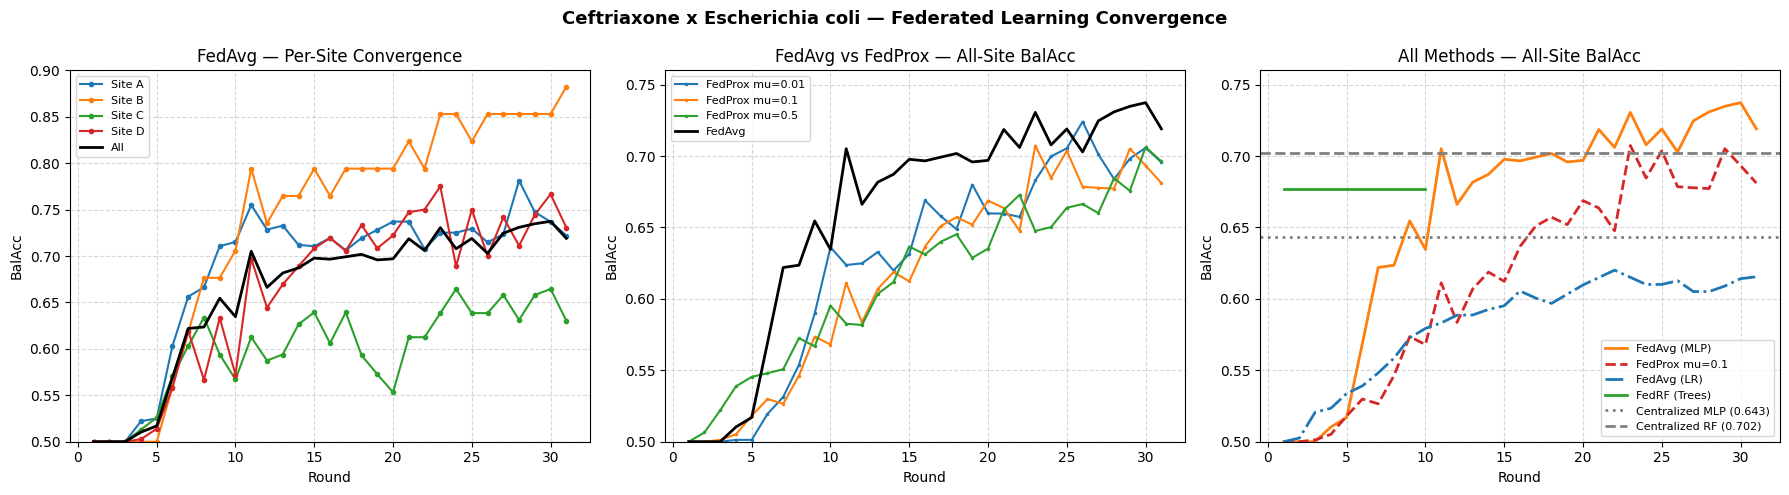

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ── Convergence: All BalAcc over rounds ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FedAvg convergence per site
ax = axes[0]
for site in SITE_ORDER:
    vals = [h[f"{site}_BalAcc"] for h in fedavg_history if f"{site}_BalAcc" in h]
    ax.plot(range(1, len(vals)+1), vals, marker='o', markersize=3, label=f"Site {site}")
vals_all = [h["All_BalAcc"] for h in fedavg_history if "All_BalAcc" in h]
ax.plot(range(1, len(vals_all)+1), vals_all, 'k-', linewidth=2, label="All")
ax.set_title("FedAvg — Per-Site Convergence")
ax.set_xlabel("Round"); ax.set_ylabel("BalAcc")
ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)
ax.set_ylim(0.5, 0.9)  # User requested limit

# FedAvg vs FedProx (All BalAcc)
ax = axes[1]
for mu in FEDPROX_MUS:
    h = fedprox_histories[mu]
    vals = [r.get("All_BalAcc", np.nan) for r in h]
    ax.plot(range(1, len(vals)+1), vals, marker='.', markersize=3, label=f"FedProx mu={mu}")
vals = [r.get("All_BalAcc", np.nan) for r in fedavg_history]
ax.plot(range(1, len(vals)+1), vals, 'k-', linewidth=2, label="FedAvg")
ax.set_title("FedAvg vs FedProx — All-Site BalAcc")
ax.set_xlabel("Round"); ax.set_ylabel("BalAcc")
ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)
ax.set_ylim(0.5, 0.76) # User requested limit

# All methods
ax = axes[2]
for label, hist, color, ls in [
    ("FedAvg (MLP)", fedavg_history, "#ff7f0e", "-"),
    ("FedProx mu=0.1", fedprox_histories[0.1], "#d62728", "--"),
    ("FedAvg (LR)", fedlr_history, "#1f77b4", "-."),
    ("FedRF (Trees)", fedrf_history, "#2ca02c", "-"),
]:
    vals = [r.get("All_BalAcc", np.nan) for r in hist]
    ax.plot(range(1, len(vals)+1), vals, color=color, ls=ls, linewidth=2, label=label)
ax.axhline(centralized_results["All_BalAcc"], color='gray', ls=':', linewidth=2,
           label=f'Centralized MLP ({centralized_results["All_BalAcc"]:.3f})')
ax.axhline(centralized_rf_results["All_BalAcc"], color='gray', ls='--', linewidth=2,
           label=f'Centralized RF ({centralized_rf_results["All_BalAcc"]:.3f})')
ax.set_title("All Methods — All-Site BalAcc")
ax.set_xlabel("Round"); ax.set_ylabel("BalAcc")
ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)
ax.set_ylim(0.5, 0.76) # User requested limit

fig.suptitle(f"{DRUG} x {SPECIES} — Federated Learning Convergence", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "convergence.pdf", bbox_inches="tight")
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/backends/backend_pdf.py:1761: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


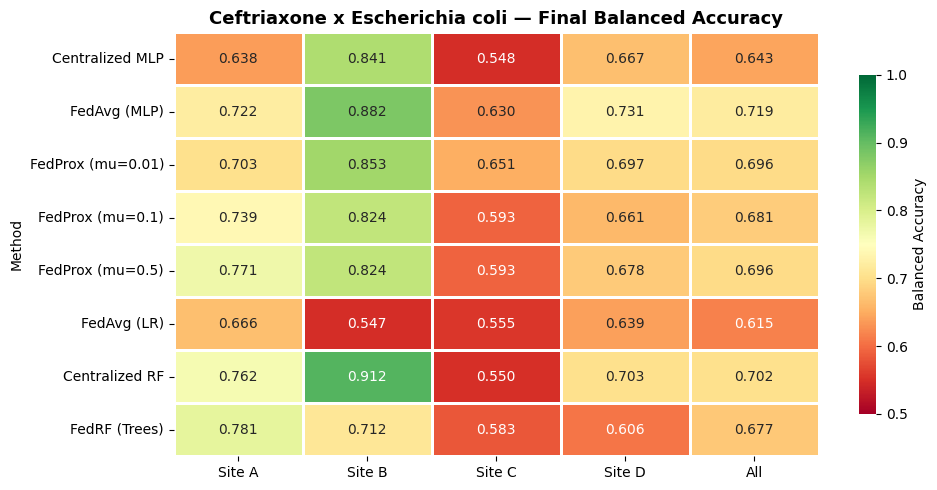

In [46]:
# ── Heatmap: Balanced Accuracy (methods x sites) ──
ba_data = {}
for _, r in df_results.iterrows():
    meth = r["Method"]
    ba_data[meth] = {f"Site {s}": r[f"{s}_BalAcc"] for s in SITE_ORDER}
    ba_data[meth]["All"] = r["All_BalAcc"]

df_ba_hm = pd.DataFrame(ba_data).T
df_ba_hm = df_ba_hm[[f"Site {s}" for s in SITE_ORDER] + ["All"]]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_ba_hm, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.5, vmax=1.0, linewidths=1.0, linecolor="white",
            cbar_kws={"label": "Balanced Accuracy", "shrink": 0.8}, ax=ax)
ax.set_title(f"{DRUG} x {SPECIES} — Final Balanced Accuracy", fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Method")
plt.tight_layout()
plt.savefig(OUT_DIR / "heatmap_balacc.pdf", bbox_inches="tight")
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/backends/backend_pdf.py:1761: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


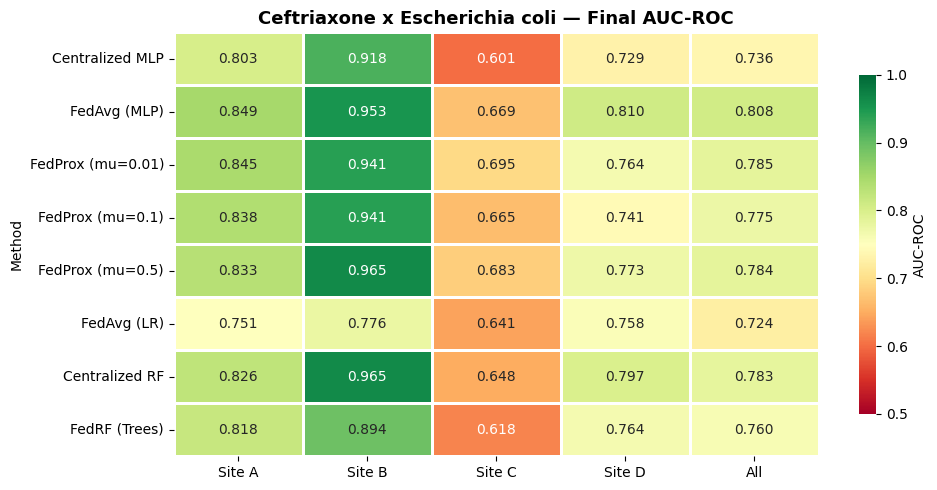

In [47]:
# ── Heatmap: AUC (methods x sites) ──
auc_data = {}
for _, r in df_results.iterrows():
    meth = r["Method"]
    auc_data[meth] = {f"Site {s}": r[f"{s}_AUC"] for s in SITE_ORDER}
    auc_data[meth]["All"] = r["All_AUC"]

df_auc_hm = pd.DataFrame(auc_data).T
df_auc_hm = df_auc_hm[[f"Site {s}" for s in SITE_ORDER] + ["All"]]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_auc_hm, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.5, vmax=1.0, linewidths=1.0, linecolor="white",
            cbar_kws={"label": "AUC-ROC", "shrink": 0.8}, ax=ax)
ax.set_title(f"{DRUG} x {SPECIES} — Final AUC-ROC", fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Method")
plt.tight_layout()
plt.savefig(OUT_DIR / "heatmap_auc.pdf", bbox_inches="tight")
plt.show()

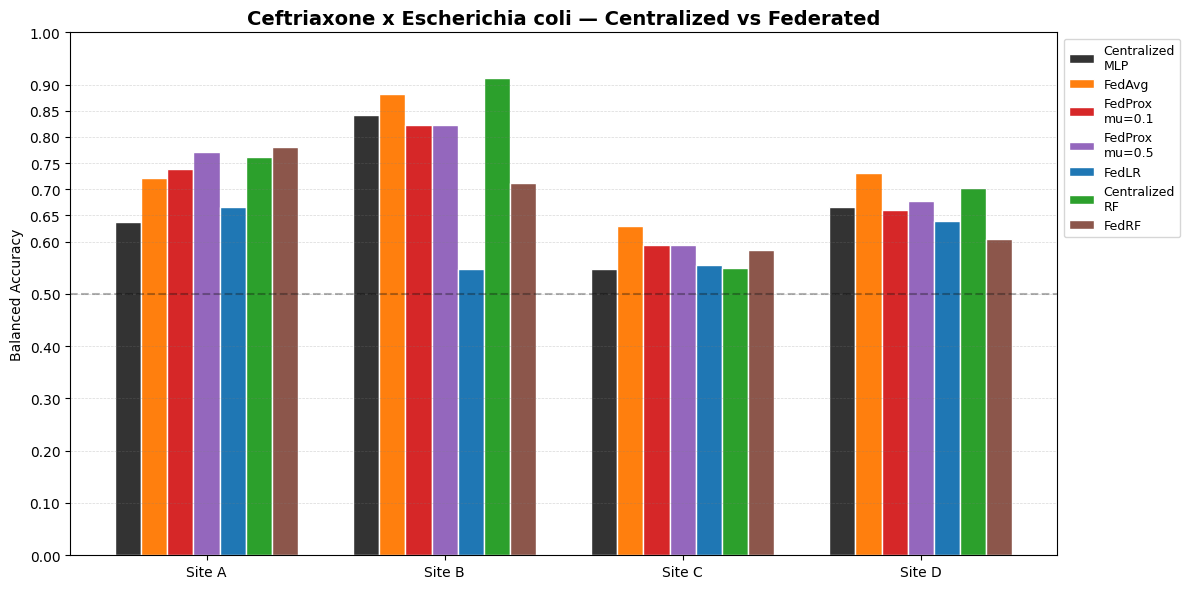

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [49]:
import numpy as np
import matplotlib.pyplot as plt

# ── Centralized vs Federated gap bar chart ──
fig, ax = plt.subplots(figsize=(12, 6))
methods_short = ["Centralized\nMLP", "FedAvg", f"FedProx\nmu=0.1", f"FedProx\nmu=0.5", "FedLR", "Centralized\nRF", "FedRF"]
x = np.arange(len(SITE_ORDER))
w = 0.11
colors = ["#333333", "#ff7f0e", "#d62728", "#9467bd", "#1f77b4", "#2ca02c", "#8c564b"]

for i, (label, row_idx) in enumerate(zip(methods_short, [0, 1, 3, 4, 5, 6, 7])):
    vals = [df_results.iloc[row_idx][f"{s}_BalAcc"] for s in SITE_ORDER]
    bars = ax.bar(x + (i - 3) * w, vals, w, label=label, color=colors[i], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"Site {s}" for s in SITE_ORDER])
ax.set_ylabel("Balanced Accuracy")
ax.set_title(f"{DRUG} x {SPECIES} — Centralized vs Federated", fontsize=14, fontweight='bold')

# Custom y-axis ticks for better granularity in the 0.6-0.9 range
y_ticks = np.sort(np.unique(np.concatenate([
    np.arange(0, 0.6, 0.1),
    np.arange(0.6, 0.95, 0.05),
    [1.0]
])))
ax.set_yticks(y_ticks)

ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
ax.set_ylim(0, 1)
ax.axhline(0.5, color="black", ls="--", alpha=0.3, label="Baseline (0.5)")
ax.grid(True, ls='--', lw=0.5, color='gray', alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / "centralized_vs_fl.pdf", bbox_inches="tight")
plt.show()

In [52]:
# ── Data summary table ──
print("\n" + "="*60)
print("  DATA SUMMARY")
print("="*60)
for site in SITE_ORDER:
    X_tr, y_tr = client_train[site]
    X_te, y_te = client_test[site]
    print(f"  Site {site}: train={len(X_tr)} (R={(y_tr==1).sum()})  test={len(X_te)} (R={(y_te==1).sum()})")
print(f"  Pooled: train={len(pooled_X_train)} (R={(y_pooled==1).sum()})")
print(f"  All test: {combined_X_test.shape[0]} (R={(combined_y_test==1).sum()})")


  DATA SUMMARY
  Site A: train=1247 (R=230)  test=139 (R=26)
  Site B: train=191 (R=40)  test=22 (R=5)
  Site C: train=821 (R=133)  test=92 (R=15)
  Site D: train=1794 (R=178)  test=200 (R=20)
  Pooled: train=4053 (R=581)
  All test: 453 (R=66)


In [53]:
# ── Save numeric results ──
df_results.to_csv(OUT_DIR / "final_results.csv", index=False)
pd.DataFrame(fedavg_history).to_csv(OUT_DIR / "fedavg_per_round.csv", index=False)
for mu in FEDPROX_MUS:
    pd.DataFrame(fedprox_histories[mu]).to_csv(
        OUT_DIR / f"fedprox_mu{mu}_per_round.csv", index=False)
pd.DataFrame(fedlr_history).to_csv(OUT_DIR / "fedlr_per_round.csv", index=False)

# Save best params
with open(OUT_DIR / "best_params.txt", "w") as f:
    f.write(f"BEST_LR={BEST_LR}\nBEST_DH={BEST_DH}\nBEST_THRESH={BEST_THRESH}\n")

print("\nSaved to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*")):
    print(f"  {f.name}")


Saved to /content/results_federated
  best_params.txt
  centralized_vs_fl.pdf
  convergence.pdf
  fedavg_per_round.csv
  fedlr_per_round.csv
  fedprox_mu0.01_per_round.csv
  fedprox_mu0.1_per_round.csv
  fedprox_mu0.5_per_round.csv
  final_results.csv
  heatmap_auc.pdf
  heatmap_balacc.pdf


---
**Done.** Federated learning analysis complete.

### Key outputs

| File | Content |
|---|---|
| `convergence.pdf` | Per-round BalAcc progression (FedAvg per-site, FedAvg vs FedProx, all methods) |
| `heatmap_balacc.pdf` | Final BalAcc: methods x sites |
| `heatmap_auc.pdf` | Final AUC: methods x sites |
| `centralized_vs_fl.pdf` | Per-site bar chart: centralized vs FedAvg vs FedProx vs FedLR |
| `*_per_round.csv` | Per-round metrics for each federation run |
| `final_results.csv` | Aggregated final results for all methods |